In [9]:
import pandas as pd

In [10]:
cleaned_data = pd.read_csv("../../../data/balanced_dataset_30k.csv")

In [11]:
cleaned_data.head()

,text,label
0,20 year old depressed college girl with severe...,1.0
1,why is my depressed girlfriend ignoring me? so...,1.0
2,til dan rowan of the tv show rowan and martin'...,0.0
3,befriending the void,0.0
4,avoiding going to bed because i don t want to ...,1.0


In [12]:
from sklearn.model_selection import train_test_split

# Split text and labels first to avoid fitting the vectorizer on test data.
X = cleaned_data["text"]
y = cleaned_data["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((20995,), (5249,), (20995,), (5249,))

In [13]:
from src.training.preprocess import preprocess_text

# Apply preprocessing after split
X_train_preprocessed = X_train.apply(lambda x: preprocess_text(x))
X_test_preprocessed = X_test.apply(lambda x: preprocess_text(x))

print(f"Original X_train[0]:\n{X_train.iloc[0][:200]}\n")
print(f"Preprocessed X_train[0]:\n{X_train_preprocessed.iloc[0][:200]}")

Original X_train[0]:
are you succeeding at avoiding the one thing you should be doing? i want to immediately address that somebody will see this as me being a smart ass and thats not the mission here if reading this hits 

Preprocessed X_train[0]:
succeeding avoiding one thing ? want immediately address somebody see smart as thats not mission reading hit nerve id advise step taken numtoken close tab numtoken get snack numtoken think real reason


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fit TF-IDF on preprocessed training text only, then transform test text.
vectorizer = TfidfVectorizer(
    max_features=10000,
    # stop_words='english',  # Already removed during preprocessing
    # min_df=0.001, max_df=0.999
)

X_train = vectorizer.fit_transform(X_train_preprocessed)
X_test = vectorizer.transform(X_test_preprocessed)
print(type(X_train), X_train.shape, X_test.shape)

BOW_train = pd.DataFrame.sparse.from_spmatrix(
    X_train,
    index=y_train.index,
    columns=vectorizer.get_feature_names_out(),
)

<class 'scipy.sparse._csr.csr_matrix'> (20995, 10000) (5249, 10000)


In [15]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)
log_reg.score(X_test, y_test)

0.9255096208801676

In [23]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,  # Plus d'arbres
    max_depth=8,  # Plus profond
    learning_rate=0.05,  # Plus lent mais précis
    subsample=0.8,  # Régularisation
    colsample_bytree=0.8,  # Diversité features
    scale_pos_weight=4.2,  # Ratio 80/20 inversé (0.8078/0.1922)
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
)

In [27]:
model = xgb_model.fit(X_train, y_train, verbose=False)

array([1, 0, 0, ..., 1, 1, 1], shape=(5249,))

In [16]:
import sys
from pathlib import Path

# Ensure the project root (folder containing `src`) is importable in this notebook kernel.
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()), None)
if project_root is None:
    raise RuntimeError("Could not locate project root containing `src`.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Using project root: {project_root}")

Using project root: /home/thomas_d/code/Projet/mental-health-signal-detector


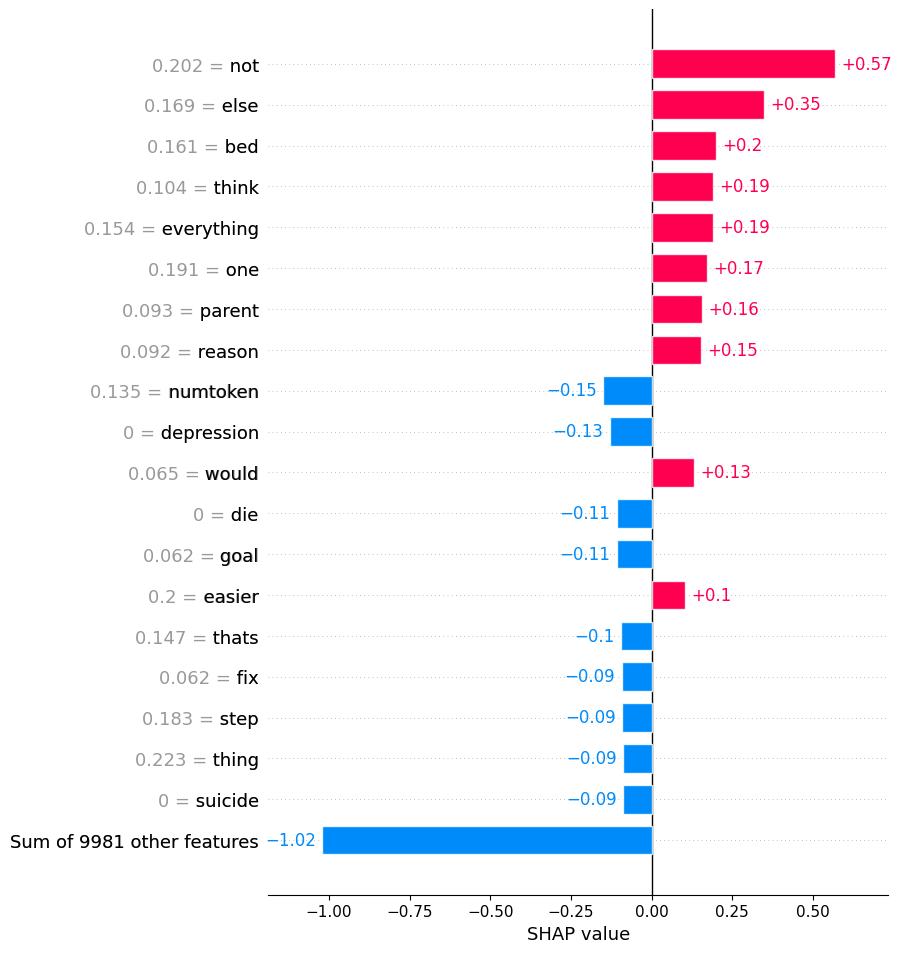

<Figure size 640x480 with 0 Axes>

In [28]:
from src.dashboard.shap import shap_graph

shap_graph(model=log_reg, X_train=X_train, vectorizer=vectorizer, sample_size=None)

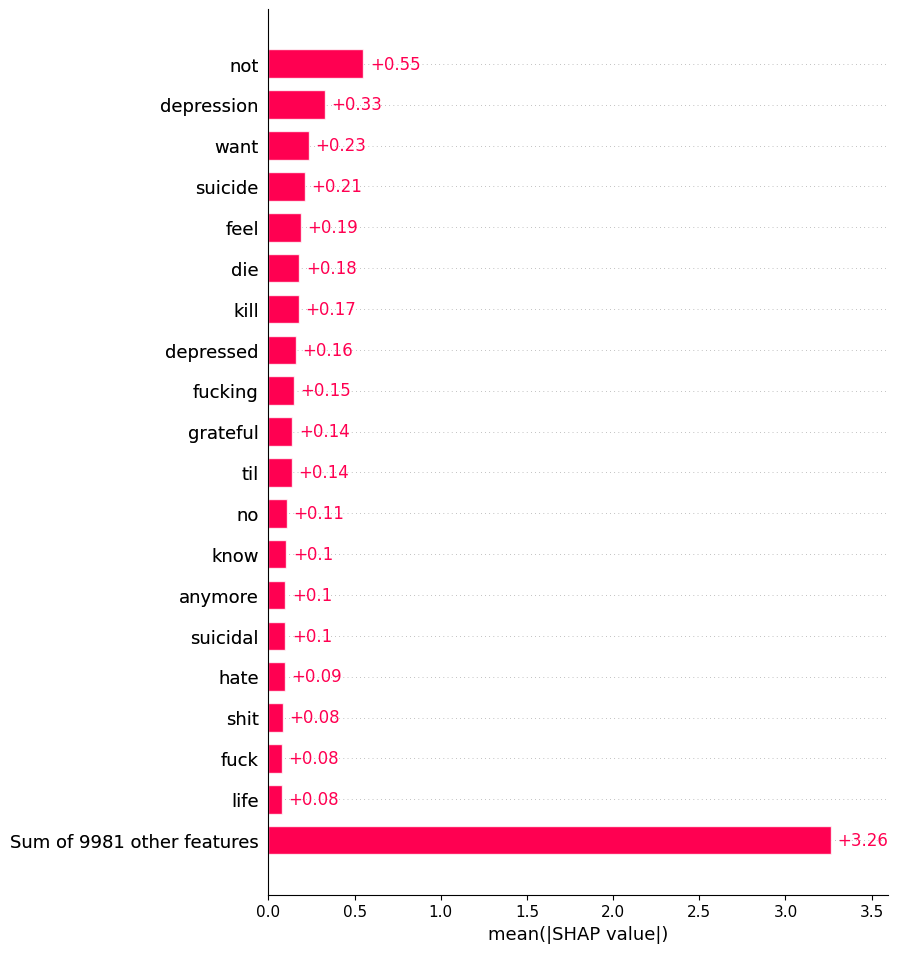

In [31]:
import shap

# For XGBoost + sparse TF-IDF, do not pass X_train as background masker.
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

feature_names = vectorizer.get_feature_names_out().tolist()
shap_values.feature_names = feature_names

# Global feature importance bar plot
shap.plots.bar(shap_values, max_display=20)

In [32]:
word_importance = dict(zip(feature_names, shap_values.values[0]))
word_importance_sorted = dict(sorted(word_importance.items(), key=lambda item: abs(item[1]), reverse=True))
word_importance_sorted

{'not': np.float32(0.86803114),
 'goal': np.float32(-0.6338108),
 'know': np.float32(0.35228875),
 'actually': np.float32(-0.2579449),
 'depression': np.float32(-0.20158564),
 'without': np.float32(-0.15625393),
 'time': np.float32(-0.1522044),
 'want': np.float32(0.1501442),
 'one': np.float32(0.1100679),
 'everything': np.float32(0.10872325),
 'numtoken': np.float32(-0.0966956),
 'no': np.float32(-0.09556182),
 'suicide': np.float32(-0.08513912),
 'think': np.float32(0.08408305),
 'die': np.float32(-0.07948397),
 'whatever': np.float32(-0.06944873),
 'friend': np.float32(-0.069048546),
 'right': np.float32(-0.06895688),
 'kill': np.float32(-0.06781941),
 'fix': np.float32(-0.06638881),
 'depressed': np.float32(-0.06596813),
 'fucking': np.float32(-0.06413518),
 'anymore': np.float32(-0.060297865),
 'need': np.float32(-0.058258053),
 'thing': np.float32(-0.056252565),
 'like': np.float32(-0.050022066),
 'feel': np.float32(-0.047572475),
 'going': np.float32(-0.044436518),
 'threedots'